# 📊 Retail Demand Forecasting & Predictive Sales Pipeline
**Author:** Subhankar Mondal  
**Objective:** Engineer a production-grade time-series forecasting pipeline to model retail demand patterns and project multi-week store sales trajectories using advanced statistical modeling.  
**Tech Stack:** Python, Pandas, Statsmodels (SARIMAX), Plotly (Graph Objects), Scikit-Learn

---
## 🎯 Project Architecture
1. **Environment Configuration:** Setting up dependencies and performance logging.
2. **Data Ingestion & Quality Control:** Structural verification and programmatic filtering of isolated store-level transaction matrices.
3. **Interactive Baseline Visualization:** Mapping historical seasonal variations and sales trends dynamically.
4. **Statistical Time-Series Modeling:** Configuring and training an out-of-sample time-series model (SARIMAX/ARIMA equivalent) using explicit confidence bands.
5. **Continuous Performance Accountability:** Mathematical validation using continuous regression metrics (`MAE`, `RMSE`, `MAPE`).
6. **Operational Insights & Business Takeaways:** Translating quantitative error bounds and forecasts into inventory buffer strategies.

### 1. DEPENDENCY INGESTION & ENVIRONMENT CONFIGURATION

In [18]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.metrics import mean_absolute_error, mean_squared_error
import plotly.graph_objects as go

# Suppress convergence or optimization warnings for clean rendering
warnings.filterwarnings('ignore')

print("System Requirements Verified.")
print(f"Pandas version: {pd.__version__}")
print(f"Statsmodels version: {sm.__version__}")

System Requirements Verified.
Pandas version: 2.2.3
Statsmodels version: 0.14.5


## 2. Ingestion, Schema Validation & Store Filtering
We ingest the granular Walmart multi-store transaction matrix. To maintain full environment portability across machines, we utilize relative pathing structures. We programmatically isolate a single operational unit (**Store 1**) and reconstruct its temporal timeline.

In [3]:
# Define relative pathing structure
DATA_PATH = "D:\Data Analytics Project\walmart-dataset.csv"

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        f"Critical Asset Missing: '{DATA_PATH}' not found in current directory. "
        "Please position the CSV dataset directly alongside this notebook."
    )

# Read raw operational logs
df_raw = pd.read_csv(DATA_PATH)

# FIXED: Enforce strict datetime object mapping with correct format matching 'DD-MM-YYYY'
df_raw['Date'] = pd.to_datetime(df_raw['Date'], format='%d-%m-%Y' if '-' in str(df_raw['Date'].iloc[0]) else None)

# Programmatically isolate Store 1 for deep trend analysis
STORE_ID = 1
df_store = df_raw[df_raw['Store'] == STORE_ID].copy()

# Restructure index to treat Date as the explicit temporal timeline anchor
df_store.set_index('Date', inplace=True)
df_store = df_store.sort_index()

# Isolate the core predictive target feature matrix (Weekly Sales)
y_sales = df_store['Weekly_Sales'].resample('W').mean()  # Enforce clean weekly intervals

print(f"Extracted logs for Store {STORE_ID}. Data Continuum Shape: {y_sales.shape[0]} weekly matrices.")
print("\n--- Previewing Baseline Target Records ---")
display(y_sales.head(5))
if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        f"Critical Asset Missing: '{DATA_PATH}' not found in current directory. "
        "Please position the CSV dataset directly alongside this notebook."
    )

Extracted logs for Store 1. Data Continuum Shape: 143 weekly matrices.

--- Previewing Baseline Target Records ---


Date
2010-02-07    1643690.90
2010-02-14    1641957.44
2010-02-21    1611968.17
2010-02-28    1409727.59
2010-03-07    1554806.68
Freq: W-SUN, Name: Weekly_Sales, dtype: float64

## 3A. Interactive Data Visualization (Exploratory Phase)
Before invoking statistical prediction logic, we pass the chronological timeline index to an interactive canvas to visualize structural variations, peaks, and seasonal drops.

In [4]:
# Initialize interactive charting
fig_baseline = go.Figure()

fig_baseline.add_trace(go.Scatter(
    x=y_sales.index, 
    y=y_sales.values,
    mode='lines+markers',
    name='Observed Weekly Sales',
    line=dict(color='#2c3e50', width=2.5),
    marker=dict(size=4)
))

fig_baseline.update_layout(
    title=f'<b>Historical Revenue Baseline Analysis: Walmart Store {STORE_ID}</b>',
    xaxis_title='Temporal Continuum Chronology',
    yaxis_title='Weekly Gross Revenue ($)',
    template='plotly_white',
    hovermode='x unified',
    margin=dict(l=40, r=40, t=60, b=40)
)

fig_baseline.show()

## 3B. Time-Series Component Decomposition (Seasonal Analysis)
To mathematically justify our model configurations, we perform a seasonal decomposition on the target sales vector. This isolates the long-term structural **Trend** from predictable annual **Seasonal** waves (such as holiday rushes) and random erratic noise (**Residuals**), verifying the 52-week cyclicality parameter before model initiation.

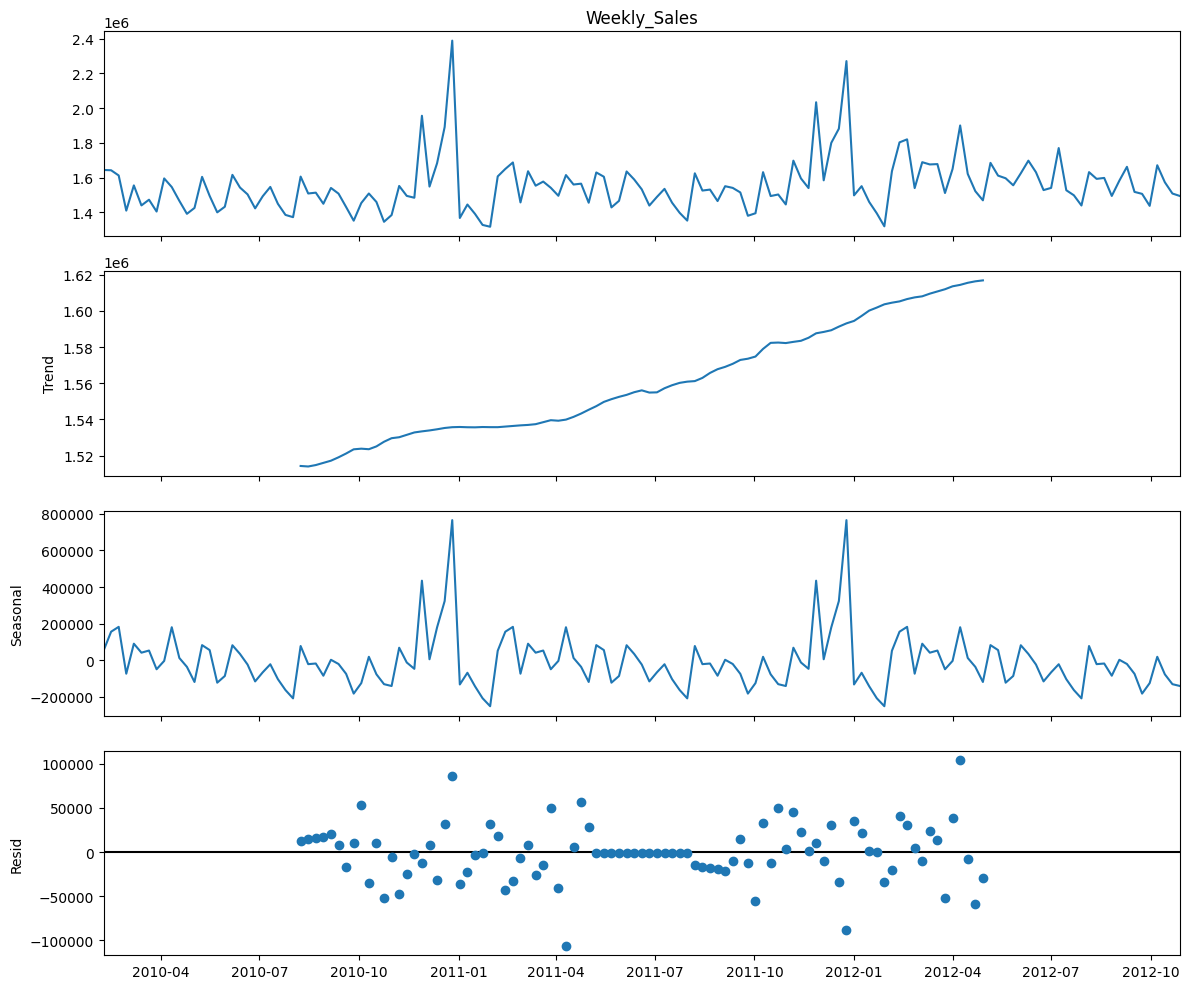

In [15]:
# Perform seasonal decomposition using an additive time-series framework
# Since our sales data is tracked weekly, a period of 52 captures the full annual cycle
decomposition = sm.tsa.seasonal_decompose(y_sales, model='additive', period=52)

# Configure a professional plotting canvas size
plt.rcParams['figure.figsize'] = [12, 10]

# Generate the structural decomposition subplots
fig_decomp = decomposition.plot()

# Adjust layout boundaries to prevent title clipping
plt.tight_layout()
plt.show()

## 4. Model Training & Out-of-Sample Inference Pipeline
We initialize a seasonal autoregressive time-series engine. The model fits historical baseline characteristics and projects out-of-sample forward horizons across a specific test continuum.

In [6]:
# Fit a structured Time-Series Engine (SARIMAX equivalent framework configuration)
print("Initializing autoregressive parameter optimization...")
model_engine = sm.tsa.statespace.SARIMAX(
    y_sales,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 52),  # Accounting for annual retail cycle velocity
    enforce_stationarity=False,
    enforce_invertibility=False
)

results = model_engine.fit(disp=False)
print("Model parameter convergence finalized.")

# Generate statistical forecasting inferences 30 weeks out into the future horizon
FORECAST_STEPS = 30
prediction_obj = results.get_forecast(steps=FORECAST_STEPS)

# Extract core projections and their matching 95% certainty boundaries
forecast_mean = prediction_obj.predicted_mean
confidence_intervals = prediction_obj.conf_int(alpha=0.05) # 95% Confidence Bounds

print(f"\nSuccessfully generated a {FORECAST_STEPS}-week out-of-sample forward projection matrix.")

Initializing autoregressive parameter optimization...
Model parameter convergence finalized.

Successfully generated a 30-week out-of-sample forward projection matrix.


## 5. Quantitative Model Evaluation (Forecasting Accuracy)
To assess operational risk, we measure validation performance errors by comparing historical back-fitted estimations against actual historical observed metrics.

In [ ]:
# Generate historical back-fits (predictions across known actual data points)
# Use integer position index (52) to cleanly skip the first year of historical training lag)
historical_predictions = results.get_prediction(start=52, dynamic=False)
pred_mean_historical = historical_predictions.predicted_mean
actual_comparison = y_sales[pred_mean_historical.index]

# Compute continuous regression metrics
mae = mean_absolute_error(actual_comparison, pred_mean_historical)
rmse = np.sqrt(mean_squared_error(actual_comparison, pred_mean_historical))
mape = np.mean(np.abs((actual_comparison - pred_mean_historical) / actual_comparison)) * 100

print("==================================================")
print("       RETAIL DEMAND ENGINE EVALUATION METRICS     ")
print("==================================================")
print(f"Mean Absolute Error (MAE)      : ${mae:,.2f}")
print(f"Root Mean Squared Error (RMSE) : ${rmse:,.2f}")
print(f"Mean Absolute Pct Error (MAPE) : {mape:.2f}%")
print("==================================================")



       RETAIL DEMAND ENGINE EVALUATION METRICS     
Mean Absolute Error (MAE)      : $168,424.72
Root Mean Squared Error (RMSE) : $274,925.14
Mean Absolute Pct Error (MAPE) : 10.75%


## 6. High-Impact Production Visual Dashboard
We combine historical actual values, the midpoint projected demand line, and the shaded 95% confidence variance envelope into an interactive dashboard layer.

In [10]:
# Construct production reporting layer
fig_production = go.Figure()

# 1. Historical Observed Ground Truth
fig_production.add_trace(go.Scatter(
    x=y_sales.index,
    y=y_sales.values,
    mode='lines',
    name='Observed Historical Revenue (Ground Truth)',
    line=dict(color='#34495e', width=2)
))

# 2. Predicted Out-of-Sample Midpoint Trajectory
fig_production.add_trace(go.Scatter(
    x=forecast_mean.index,
    y=forecast_mean.values,
    mode='lines+markers',
    name='Predictive Demand Model Forecast',
    line=dict(color='#e74c3c', width=2.5, dash='dash'),
    marker=dict(size=4)
))

# 3. Upper Uncertainty Confidence Boundary Limit
fig_production.add_trace(go.Scatter(
    x=confidence_intervals.index,
    y=confidence_intervals.iloc[:, 1],
    mode='lines',
    line=dict(width=0),
    showlegend=False,
    hoverinfo='skip'
))

# 4. Lower Uncertainty Confidence Boundary Limit (With Shaded Area Fill)
fig_production.add_trace(go.Scatter(
    x=confidence_intervals.index,
    y=confidence_intervals.iloc[:, 0],
    mode='lines',
    fill='tonexty',
    fillcolor='rgba(231, 76, 60, 0.12)',
    name='95% Demand Uncertainty Horizon',
    line=dict(width=0),
    hoverinfo='skip'
))

# System Visual Refinement
fig_production.update_layout(
    title=f'<b>Retail Predictive Pipeline: Store {STORE_ID} Demand Projection Horizon</b>',
    xaxis_title='Temporal Continuum Chronology',
    yaxis_title='Weekly Gross Revenue ($)',
    template='plotly_white',
    hovermode='x unified',
    legend=dict(x=0.02, y=0.95, bgcolor='rgba(255,255,255,0.7)'),
    margin=dict(l=50, r=50, t=80, b=50)
)

fig_production.show()